In [1]:
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator

2026-06-16 16:27:19.273678: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781627239.485954      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781627239.552003      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781627240.045679      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781627240.045734      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781627240.045736      58 computation_placer.cc:177] computation placer alr

In [2]:
img = image.load_img('/kaggle/input/datasets/nicksri1248/sample-cat-dog/cat.jpg', target_size = (200, 200))

In [3]:
import matplotlib.pyplot as plt

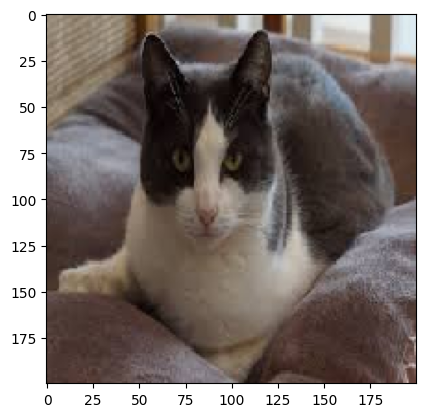

In [4]:
plt.imshow(img)

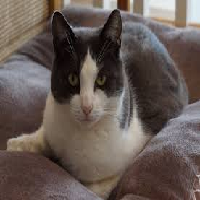

In [5]:
img

In [6]:
type(img)

PIL.Image.Image

In [7]:
datagen = ImageDataGenerator(
    rotation_range = 30,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    # fill_mode = 'reflect'
    fill_mode = 'constant'
)

In [8]:
img = image.img_to_array(img)

In [9]:
type(img)

numpy.ndarray

In [10]:
img.shape

(200, 200, 3)

In [11]:
input_batch = img.reshape(1, 200, 200, 3)

In [12]:
!mkdir aug

In [13]:
i = 0

for output in datagen.flow(input_batch, batch_size = 1, save_to_dir = 'aug'):

    i = i + 1

    if i == 10:
        break

In [14]:
input_batch.shape

(1, 200, 200, 3)

In [15]:
import cv2
import os
import random
import numpy as np

In [16]:
mydir = r'/kaggle/input/datasets/nicksri1248/dogsvscats-minimal/train'

In [17]:
categories = ['cats', 'dogs']

In [18]:
data = []

for i in categories:

    folder_path = os.path.join(mydir, i)

    if i == 'cats':
        label = 0
    else:
        label = 1

    for j in os.listdir(folder_path):

        img_path = os.path.join(folder_path, j)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (150, 150))
        data.append([img, label])

In [19]:
random.shuffle(data)

In [20]:
X = []
y = []
for i in data:

    X.append(i[0])
    y.append(i[1])

In [21]:
y = np.array(y)

In [22]:
X = np.array(X)

In [23]:
X.shape

(2000, 150, 150, 3)

In [24]:
X = X/255

In [25]:
# Create CNN from here

from keras import Sequential
from keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Activation, Dropout

In [26]:
model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape = (150, 150, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1781627269.048036      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [27]:
model.add(Flatten()) # this converts our 3D feature maps to 1D feature vectors
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss = 'binary_crossentropy',
             optimizer = 'rmsprop',
             metrics = ['accuracy'])

In [28]:
model.fit(X, y, epochs = 5, validation_split = 0.1)

Epoch 1/5


I0000 00:00:1781627273.030153     130 service.cc:152] XLA service 0x78f7ec086fa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781627273.030208     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1781627273.387454     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


13/57 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.4614 - loss: 0.7987

I0000 00:00:1781627276.679507     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


57/57 ━━━━━━━━━━━━━━━━━━━━ 9s 78ms/step - accuracy: 0.5106 - loss: 0.7066 - val_accuracy: 0.5700 - val_loss: 0.6922
Epoch 2/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5322 - loss: 0.6934 - val_accuracy: 0.4800 - val_loss: 0.7015
Epoch 3/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.5744 - loss: 0.6794 - val_accuracy: 0.5500 - val_loss: 0.6547
Epoch 4/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6594 - loss: 0.6313 - val_accuracy: 0.6400 - val_loss: 0.6240
Epoch 5/5
57/57 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6739 - loss: 0.6046 - val_accuracy: 0.6500 - val_loss: 0.6209


In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [30]:
batch_size = 16

# this is the augmentation configuration we will use for training
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)

# this is the augmentation configuration we will use for testing:
# only rescaling
test_datagen = ImageDataGenerator(rescale = 1./255)

# this is a generator that will read pictures found in
# subfolders of 'data/train', and indefinitely generate
# batches of augmented image data
train_generator = train_datagen.flow_from_directory(
    '/kaggle/input/datasets/nicksri1248/dogsvscats-minimal/train',	# this is the target directory
    target_size = (150, 150),  # all images will be resized to 150x150
    batch_size = batch_size,
    class_mode = 'binary'  # since we use binary_crossentropy loss, we need binary labels
)

# this is a similar generator, for validation data
validation_generator = test_datagen.flow_from_directory(
    '/kaggle/input/datasets/nicksri1248/dogsvscats-minimal/valid',
    target_size = (150, 150),
    batch_size = batch_size,
    class_mode = 'binary'
)

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.


In [31]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import Activation, Dropout, Flatten, Dense

model = Sequential()
model.add(Conv2D(32, (3, 3), input_shape = (150, 150, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(32, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(64, (3, 3)))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

In [32]:
model.add(Flatten()) # this converts our 3D feature maps to 1D feature vectors
model.add(Dense(64))
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(1))
model.add(Activation('sigmoid'))

model.compile(loss = 'binary_crossentropy',
             optimizer = 'rmsprop',
             metrics = ['accuracy'])

In [33]:
# model.fit_generator(train_generator,
#                     steps_per_epoch = 2000 // batch_size,
#                     epochs = 25,
#                    validation_data = validation_generator,
#                    validation_steps = 800 // batch_size)

model.fit(train_generator,
          steps_per_epoch = 2000 // batch_size,
          epochs = 25,
          validation_data = validation_generator,
          validation_steps = 800 // batch_size)

Epoch 1/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 22s 150ms/step - accuracy: 0.5135 - loss: 0.7016 - val_accuracy: 0.5238 - val_loss: 0.6883
Epoch 2/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 128ms/step - accuracy: 0.5810 - loss: 0.6848 - val_accuracy: 0.6175 - val_loss: 0.6702
Epoch 3/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.6390 - loss: 0.6498 - val_accuracy: 0.6200 - val_loss: 0.6363
Epoch 4/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - accuracy: 0.6580 - loss: 0.6221 - val_accuracy: 0.6762 - val_loss: 0.6120
Epoch 5/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 124ms/step - accuracy: 0.6720 - loss: 0.6042 - val_accuracy: 0.6700 - val_loss: 0.5913
Epoch 6/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.6850 - loss: 0.5925 - val_accuracy: 0.6837 - val_loss: 0.5834
Epoch 7/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 16s 125ms/step - accuracy: 0.6980 - loss: 0.5704 - val_accuracy: 0.7050 - val_loss: 0.5626
Epoch 8/25
125/125 ━━━━━━━━━━━━━━━━━━━━ 15s 123ms/step - accuracy: 0.7255 - loss: 0